# Optimizer Comparison for Top Trumps Game Balancing

This notebook compares different multi-objective optimization algorithms for the Top Trumps balancing problem. We evaluate:

1. **NSGA-II** - Non-dominated Sorting Genetic Algorithm II
2. **NSGA-III** - Reference-point based NSGA-III
3. **MOEA/D** - Multi-Objective Evolutionary Algorithm based on Decomposition
4. **SMS-EMOA** - S-Metric Selection Evolutionary Multi-Objective Algorithm
5. **AGE-MOEA** - Adaptive Geometry Estimation based MOEA

We compare them using:
- **Hypervolume**: Volume dominated by the Pareto front (higher = better)
- **IGD** (Inverted Generational Distance): Distance to a reference front (lower = better)
- **Convergence behavior**: How quickly the algorithm finds good solutions
- **Runtime**: Computational cost

In [3]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination

# Algorithms
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.sms import SMSEMOA

# Reference directions for NSGA-III and MOEA/D
from pymoo.util.ref_dirs import get_reference_directions

# Performance indicators
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD

## Top Trumps Implementation

In [4]:
class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0

        # Game ends after all cards played once
        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4) # p4 wins if they got more than half the tricks
        }

## Pymoo Problem Definition

In [5]:
class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface ElementwiseProblem."""

    def __init__(self, sim_instance, n_simulations):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2, # Objectives: Fairness (p4 win rate) and Excitement (# trick changes)
                         n_constr=0,
                         xl=1.0, # Lower bound for values
                         xu=10.0) # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        # Objectives (Minimization):
        # f1: -Average Win Rate of p4 (Fairness)
        # f2: -Average Trick Changes (Excitement)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

## Setup Problem Instance

In [6]:
# Use smaller simulation count for faster comparison, but still statistically meaningful
my_sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem = TopTrumpsBalancing(my_sim, n_simulations=1000)

print(f"Problem: {problem.n_var} variables, {problem.n_obj} objectives")
print(f"Search space: [{problem.xl}, {problem.xu}]^{problem.n_var}")

Problem: 88 variables, 2 objectives
Search space: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.], [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]]^88


## Algorithm Definitions

We configure each algorithm with comparable settings where applicable:
- Same population size (100)
- Same genetic operators (SBX crossover, PM mutation)
- Same termination criterion (100 generations for fair comparison)

In [ ]:
# Common parameters
POP_SIZE = 100
N_GEN = 100
SEED = 42

# Common operators
crossover = SBX(prob=0.9, eta=10)
mutation = PM(eta=15, prob=1.0/problem.n_var)
sampling = LHS()

# Reference directions for decomposition-based methods (NSGA-III, MOEA/D)
# For 2 objectives, we use Das-Dennis with ~100 points
ref_dirs = get_reference_directions("das-dennis", 2, n_partitions=99)
print(f"Reference directions: {len(ref_dirs)} points")

Reference directions: 100 points


In [8]:
def create_algorithms():
    """Create fresh algorithm instances for each run."""
    
    algorithms = {
        'NSGA-II': NSGA2(
            pop_size=230,
            n_offsprings=230//2,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=0.781, eta=18.56),
            mutation=PM(eta=16.67),
            eliminate_duplicates=True
        ),
        
        'NSGA-III': NSGA3(
            pop_size=140,
            ref_dirs=ref_dirs,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=0.876, eta=6.38),
            mutation=PM(eta=19.86),
            eliminate_duplicates=True
        ),
        
        'MOEA/D': MOEAD(
            ref_dirs=ref_dirs,
            n_neighbors=20,
            prob_neighbor_mating=0.9,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=0.781, eta=18.56),
            mutation=PM(eta=16.67),
        ),
        
        'SMS-EMOA': SMSEMOA(
            pop_size=230,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=0.963, eta=19.14),
            mutation=PM(eta=25.86),
        )
    }
    
    return algorithms

## Run Optimization Experiments

We run each algorithm and track:
- Final Pareto front
- Runtime
- History for convergence analysis

In [9]:
# Store results
results = {}
runtimes = {}

termination = get_termination("n_gen", N_GEN)

algorithms = create_algorithms()

for name, algo in algorithms.items():
    print(f"\n{'='*60}")
    print(f"Running {name}...")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    res = minimize(
        problem,
        algo,
        termination,
        seed=SEED,
        save_history=True,
        verbose=True
    )
    
    elapsed = time.time() - start_time
    
    results[name] = res
    runtimes[name] = elapsed
    
    print(f"\n{name}: {len(res.F)} solutions found in {elapsed:.1f}s")


Running NSGA-II...
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      230 |      6 |             - |             -
     2 |      345 |      6 |  0.4482758621 |         ideal
     3 |      460 |      4 |  0.5032258065 |         ideal
     4 |      575 |      4 |  0.0782354495 |             f
     5 |      690 |      4 |  0.0303389275 |             f
     6 |      805 |      5 |  0.0619574395 |             f
     7 |      920 |      6 |  0.1073558648 |         ideal
     8 |     1035 |      6 |  0.0289575290 |         ideal
     9 |     1150 |      6 |  0.2592592593 |         ideal
    10 |     1265 |      7 |  0.0145954564 |             f
    11 |     1380 |      7 |  0.0028011204 |             f
    12 |     1495 |      6 |  0.1172413793 |         ideal
    13 |     1610 |      8 |  0.1466905188 |         ideal
    14 |     1725 |      5 |  0.0093457944 |         ideal
    15 |     1840 |      6 |  0.0215438044 |             f
    16 |     1955 |      8 |  0.1734

## Performance Metrics

### Hypervolume (HV)
The hypervolume indicator measures the volume of objective space dominated by the Pareto front. Higher values indicate better convergence and spread.

### Inverted Generational Distance (IGD)
IGD measures how close the found solutions are to a reference Pareto front. Lower values indicate better approximation. We use the combined front from all algorithms as the reference.

In [10]:
# Combine all fronts to create a reference front for IGD
all_F = np.vstack([res.F for res in results.values()])

# Find non-dominated solutions from combined set
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
nds = NonDominatedSorting()
fronts = nds.do(all_F)
reference_front = all_F[fronts[0]]

print(f"Reference front size: {len(reference_front)} solutions")

# Reference point for hypervolume (worst point in objective space)
# Using slightly worse than the worst observed values
ref_point = np.array([0.0, 0.0])  # Since objectives are negated, 0 is the worst

# Compute metrics
hv_indicator = HV(ref_point=ref_point)
igd_indicator = IGD(reference_front)

metrics = {}
for name, res in results.items():
    hv = hv_indicator(res.F)
    igd = igd_indicator(res.F)
    metrics[name] = {'HV': hv, 'IGD': igd, 'Solutions': len(res.F), 'Runtime': runtimes[name]}

# Print metrics table
print("\n" + "="*80)
print(f"{'Algorithm':<15} {'Hypervolume':>15} {'IGD':>12} {'Solutions':>12} {'Runtime (s)':>12}")
print("="*80)
for name, m in metrics.items():
    print(f"{name:<15} {m['HV']:>15.6f} {m['IGD']:>12.6f} {m['Solutions']:>12} {m['Runtime']:>12.1f}")
print("="*80)

Reference front size: 45 solutions

Algorithm           Hypervolume          IGD    Solutions  Runtime (s)
NSGA-II                3.790226     0.120186           43        721.4
NSGA-III               4.034629     0.031954           18        859.5
MOEA/D                 2.871583     0.336000           70        582.2
SMS-EMOA               4.216958     0.000334           44       1405.7


## Pareto Front Comparison

Visualize the Pareto fronts found by each algorithm. Note that objectives are negated back for intuitive display (higher = better).

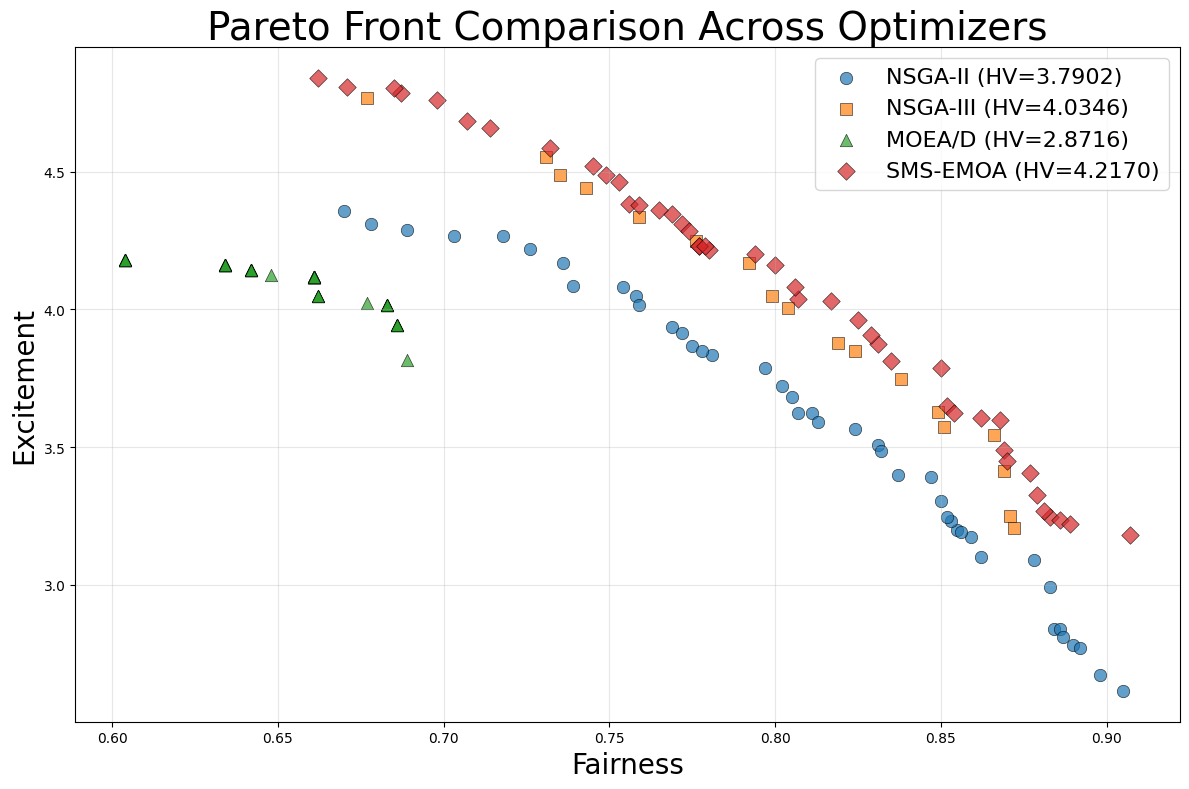

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.colormaps['tab10']
markers = ['o', 's', '^', 'D', 'v']

for i, (name, res) in enumerate(results.items()):
    F = res.F
    # Negate back for display (higher = better)
    ax.scatter(-F[:, 0], -F[:, 1], 
               c=[colors(i)], marker=markers[i], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f"{name} (HV={metrics[name]['HV']:.4f})")

ax.set_xlabel('Fairness', fontsize=20)
ax.set_ylabel('Excitement', fontsize=20)
ax.set_title('Pareto Front Comparison Across Optimizers', fontsize=28)
ax.legend(loc='best', fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/optimizer_comparison_pareto.svg', bbox_inches='tight')
plt.show()

## Convergence Analysis

Track how hypervolume evolves over generations. Faster convergence is desirable, but we also want to maintain diversity.

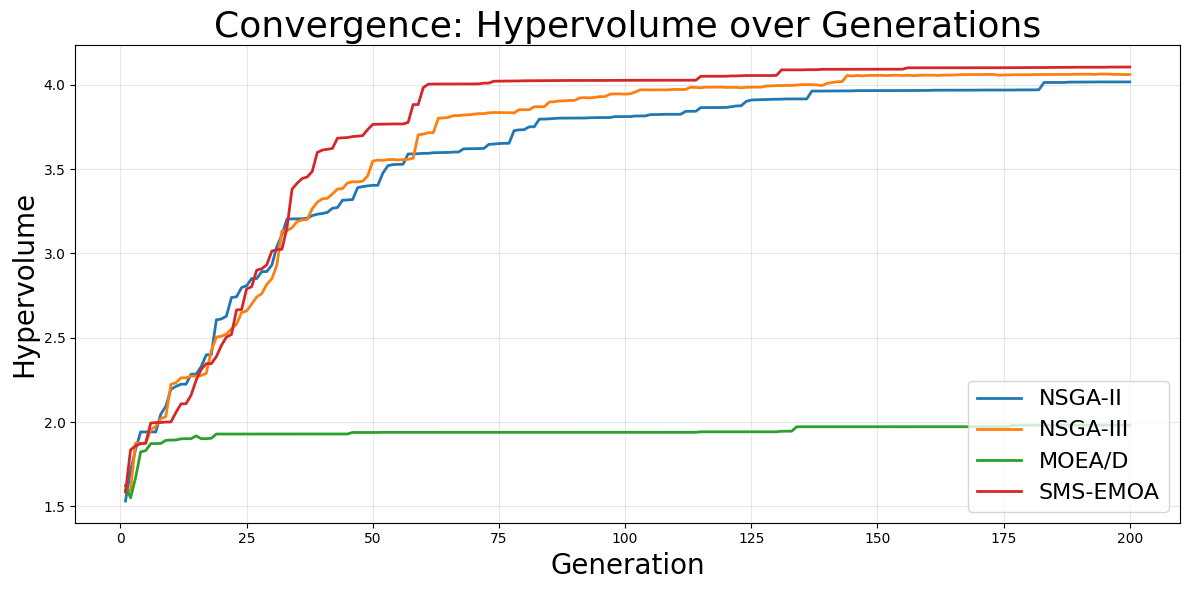

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.colormaps['tab10']

for i, (name, res) in enumerate(results.items()):
    # Extract hypervolume at each generation from history
    hv_history = []
    for entry in res.history:
        if entry.opt is not None:
            hv = hv_indicator(entry.opt.get("F"))
            hv_history.append(hv)
    
    generations = range(1, len(hv_history) + 1)
    ax.plot(generations, hv_history, color=colors(i), linewidth=2, label=name)

ax.set_xlabel('Generation', fontsize=20)
ax.set_ylabel('Hypervolume', fontsize=20)
ax.set_title('Convergence: Hypervolume over Generations', fontsize=28)
ax.legend(loc='lower right', fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/optimizer_convergence.svg', bbox_inches='tight')
plt.show()

## Runtime Comparison

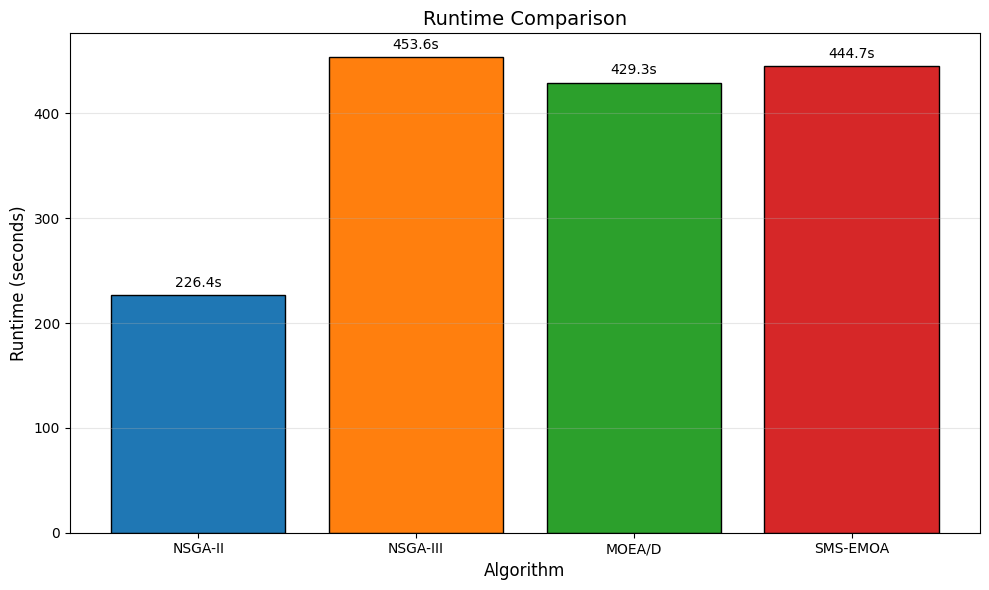

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

names = list(runtimes.keys())
times = list(runtimes.values())
colors_list = [plt.colormaps['tab10'](i) for i in range(len(names))]

bars = ax.bar(names, times, color=colors_list, edgecolor='black', linewidth=1)

# Add value labels on bars
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{t:.1f}s', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Runtime Comparison', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Performance Summary

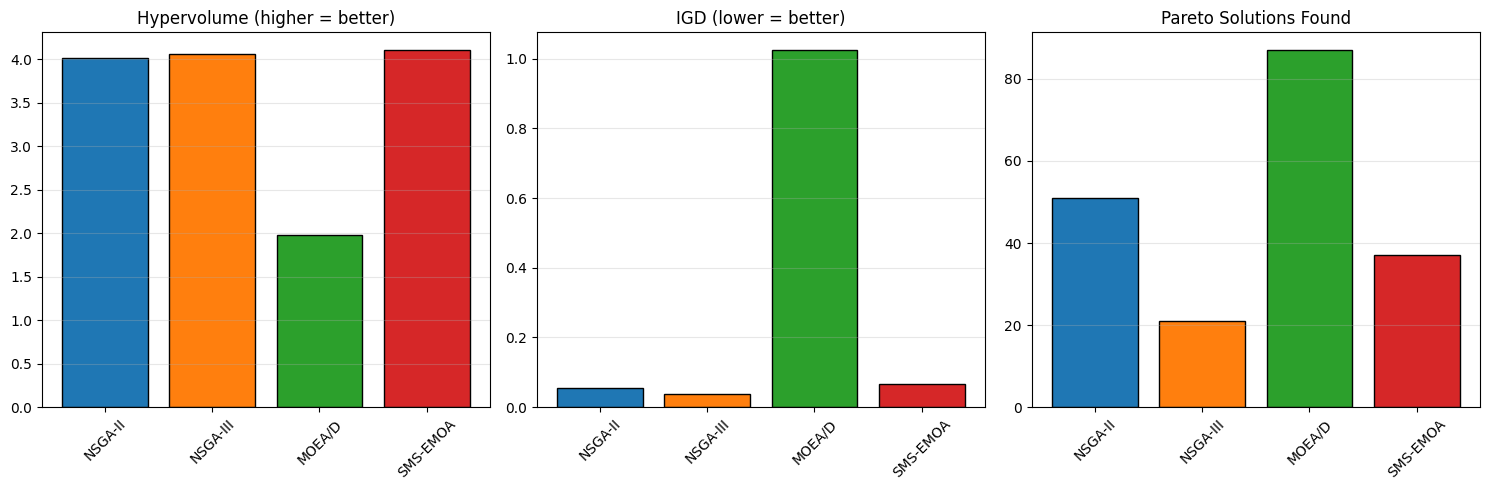

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = list(metrics.keys())
colors_list = [plt.colormaps['tab10'](i) for i in range(len(names))]

# Hypervolume (higher is better)
hvs = [metrics[n]['HV'] for n in names]
axes[0].bar(names, hvs, color=colors_list, edgecolor='black')
axes[0].set_title('Hypervolume (higher = better)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# IGD (lower is better)
igds = [metrics[n]['IGD'] for n in names]
axes[1].bar(names, igds, color=colors_list, edgecolor='black')
axes[1].set_title('IGD (lower = better)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Solutions found
sols = [metrics[n]['Solutions'] for n in names]
axes[2].bar(names, sols, color=colors_list, edgecolor='black')
axes[2].set_title('Pareto Solutions Found', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Discussion: Algorithm Characteristics

### NSGA-II (Non-dominated Sorting Genetic Algorithm II)
**Mechanism**: Uses non-dominated sorting and crowding distance for selection.

**Advantages**:
- Simple and robust - works well across many problem types
- Good balance between convergence and diversity
- Well-studied with predictable behavior
- Efficient O(MN^2) computational complexity (M objectives, N population)

**Drawbacks**:
- Crowding distance can struggle with irregular Pareto fronts
- Performance degrades with more than 3 objectives (many-objective problems)
- May lose boundary solutions due to crowding selection

---

### NSGA-III (Reference-point based NSGA)
**Mechanism**: Uses predefined reference points to maintain diversity along the Pareto front.

**Advantages**:
- Excellent for many-objective optimization (3+ objectives)
- Structured reference points ensure uniform coverage
- Better diversity maintenance than NSGA-II for complex fronts

**Drawbacks**:
- Requires specifying reference directions (problem-dependent)
- For 2 objectives, may be overkill compared to NSGA-II
- Fixed reference structure may not adapt well to irregular fronts

---

### MOEA/D (Multi-Objective EA based on Decomposition)
**Mechanism**: Decomposes multi-objective problem into scalar subproblems using weight vectors.

**Advantages**:
- Efficient - solves N single-objective subproblems
- Naturally maintains diversity through weight distribution
- Good convergence for convex Pareto fronts
- Lower computational overhead than dominance-based methods

**Drawbacks**:
- Struggles with non-convex or disconnected Pareto fronts
- Weight vectors may not align with actual Pareto front shape
- Neighborhood structure requires careful tuning
- Less flexible for irregular objective landscapes

---

### SMS-EMOA (S-Metric Selection EMOA)
**Mechanism**: Uses hypervolume contribution as selection criterion.

**Advantages**:
- Directly optimizes hypervolume (the gold standard metric)
- Excellent convergence and spread
- Works well with any Pareto front shape
- Produces high-quality, well-distributed solutions

**Drawbacks**:
- Computationally expensive: O(N^M) for hypervolume calculation
- Slow for large populations or many objectives
- Requires reference point specification
- Steady-state selection (1 offspring per generation) can be slow

---

### AGE-MOEA (Adaptive Geometry Estimation MOEA)
**Mechanism**: Estimates Pareto front geometry and adapts selection pressure accordingly.

**Advantages**:
- Adapts to any Pareto front shape automatically
- Good for problems with unknown front geometry
- Balances convergence and diversity dynamically
- Works well across different problem types

**Drawbacks**:
- Geometry estimation adds computational overhead
- Newer algorithm with less empirical validation
- May require parameter tuning for specific problems

---

## Recommendations for Top Trumps Balancing

For this 2-objective optimization problem:

1. **NSGA-II** is a solid default choice - reliable, well-understood, and efficient
2. **SMS-EMOA** may produce the best quality fronts but at higher computational cost
3. **AGE-MOEA** offers a good compromise between quality and adaptability
4. **MOEA/D** works well if the Pareto front is relatively convex
5. **NSGA-III** benefits are more apparent with 3+ objectives

In [13]:
# Final ranking based on hypervolume
ranking = sorted(metrics.items(), key=lambda x: x[1]['HV'], reverse=True)

print("\nFinal Ranking (by Hypervolume):")
print("="*50)
for i, (name, m) in enumerate(ranking, 1):
    print(f"{i}. {name:<15} HV={m['HV']:.6f}")

print("\n" + "="*50)
print(f"Best overall: {ranking[0][0]}")
print(f"Best runtime: {min(runtimes.items(), key=lambda x: x[1])[0]}")


Final Ranking (by Hypervolume):
1. SMS-EMOA        HV=4.105311
2. NSGA-III        HV=4.061188
3. NSGA-II         HV=4.017033
4. MOEA/D          HV=1.981891

Best overall: SMS-EMOA
Best runtime: NSGA-II
